<a href="https://colab.research.google.com/github/Manav010203/Quiz/blob/cloudmain/04_pytorch_custom_datasets_video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#04. Pytorch Custom Datasets Video Notebook

we've used some datasets with pytorch before.

But how do you get your own data into pytorch?

one of the ways to do so is via: custom datasets.

##Domain libraries

Depending on what u are working on, vision, text, audio, recommendation, you will want to look into each of the pytorch domain libraies for existing loading functions and customizable data loading functions.


In [543]:
import torch
from torch import nn


In [544]:
torch.__version__

'2.6.0+cu124'

In [545]:
#setup device agnostic code
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [546]:
!nvidia-smi

/bin/bash: line 1: nvidia-smi: command not found


## 1. GET DATA

our dataset is a subset of the food101 dataset.

Food101 starts 101 different classes of food and 1000 images per class (750 training, 250 testing).

Our dataset starts wiht 3 classes of foofd and only 10% of the images (~75 training,25 testing)

why do this?

when starting out ML projects, its important to try things on a small scale and then increase the scale when necessary

The whole point is to speed up how fast u can experiment

In [547]:
import requests
import zipfile
from pathlib import Path

# setup path to data folder
data_path = Path("data/")
image_path =data_path / "pizza_steak_sushi"

#if the image folder doesn't exist, download it and prepare it...
if image_path.is_dir():
  print(f"{image_path} directory exists")
else:
  print(f"{image_path} doenot exist,creating one ...")
  image_path.mkdir(parents=True,exist_ok=True)

  #download pizza, steak and sushi data
  with open(data_path/"pizza_steak_sushi.zip","wb") as f:
    requests=requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip")
    print("Downloading data..")
    f.write(requests.content)

  #unzip file
  with zipfile.ZipFile(data_path/"pizza_steak_sushi.zip","r") as zip_ref:
    print("unzippind data...")
    zip_ref.extractall(image_path)

data/pizza_steak_sushi directory exists


## 2. Becoming one with the data(data exploration and data preparation)

In [548]:
import os
def walk_through_dir(dir_path):
  """walks thorgh dir_path returning its contents..."""
  for dirpath,dirnames,filenames in os.walk(dir_path):
    print(f"there are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'")


In [549]:
walk_through_dir(image_path)

there are 2 directories and 0 images in 'data/pizza_steak_sushi'
there are 3 directories and 0 images in 'data/pizza_steak_sushi/test'
there are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'
there are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'
there are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'
there are 3 directories and 0 images in 'data/pizza_steak_sushi/train'
there are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'
there are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'
there are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'


In [550]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

# 2.1 visualizing image

lets write some code too:
1. Get all of the inage paths.
2. Pick a random image path using pythons random.choice()
3. Get the image class name using `pathlib.Path.parent.stem`
4. Since we are working wiht image ,lets open the image with pythons PIL.
5. we will then show the image and print metadata


data/pizza_steak_sushi/test/sushi/3177743.jpg
sushi
random image path:data/pizza_steak_sushi/test/sushi/3177743.jpg
Image class:sushi
Image height:512
Image width:512


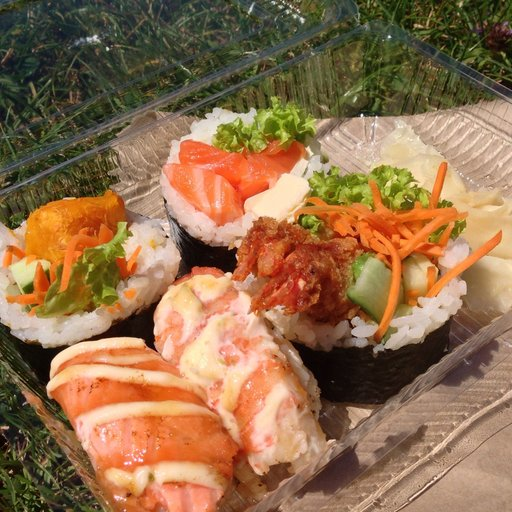

In [551]:
import random
from PIL import Image

# random.seed(42)

#1. Get all image paths
image_path_list=list(image_path.glob("*/*/*.jpg"))
# image_path_list

#2 pick a random image path

random_imag_path = random.choice(image_path_list)
print(random_imag_path)

#3 Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_imag_path.parent.stem
print(image_class)

#4 open image
img =Image.open(random_imag_path)

#5 print metadata
print(f"random image path:{random_imag_path}")
print(f"Image class:{image_class}")
print(f"Image height:{img.height}")
print(f"Image width:{img.width}")
img

Text(0.5, 1.0, 'image clas :sushi | image shape :(512, 512, 3) ')

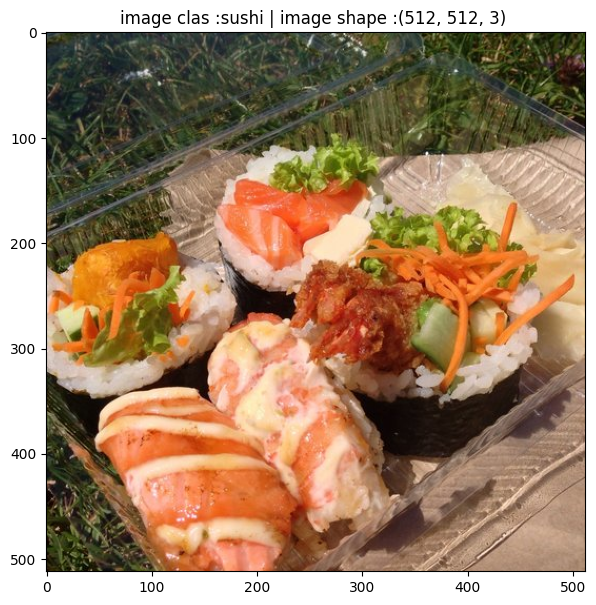

In [552]:
import matplotlib.pyplot as plt
import numpy as np
# trun image into array
imag_as_arr = np.asarray(img)
# imag_as_arr.shape


# plt.imshow(img)
plt.figure(figsize=(10,7))
plt.imshow(imag_as_arr)
plt.title(f"image clas :{image_class} | image shape :{imag_as_arr.shape} ")

## 3. Transforming data

Before we can use our image data with pytorch

1. Turn your target data into tensors (in our case, numerical representation of our images).
2. Turn it into a `torch.utils.data.Dataset` and subsequently a `torch.uti,s.data.Dataloader`, we will call these dataset and dataloader.

In [553]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

## 3.1 tranforming data with torchvision.transform

transforms help u to get image ready to perofrom augmentation

In [554]:
# write a transform for image
data_transform = transforms.Compose([
    # resize our images to 64*64
    transforms.Resize(size=(64,64)),
    #flip images randomly on horizontally
    transforms.RandomHorizontalFlip(p=0.5),
    #turn the image into torch tensor
    transforms.ToTensor()
])

In [555]:
data_transform(img).dtype

torch.float32

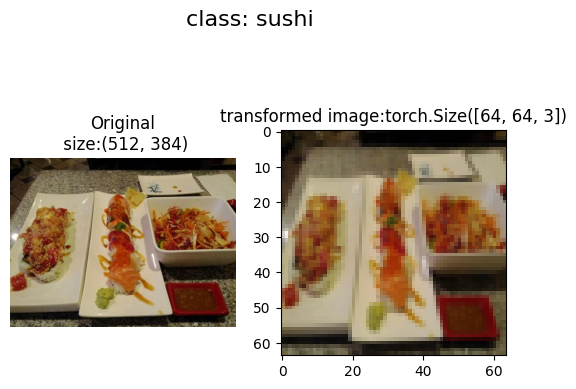

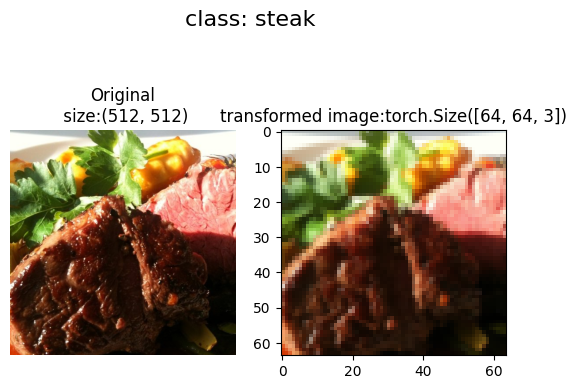

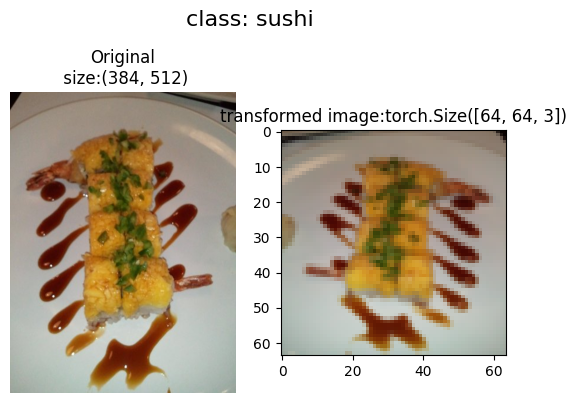

In [556]:
def plot_tranformed_images(image_paths:list,transform,n=3,seed=None):
  """
  selects random image from a path of images and loads/ transform them  then plpots the orig vs tranformed image
  """
  if seed:
    random.seed(seed)
  random_image_path = random.sample(image_paths,k=n)
  for image_path in random_image_path:
    with Image.open(image_path) as f:
      fig,ax = plt.subplots(nrows=1,ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original\n size:{f.size}")
      ax[0].axis("off")

      #transform and plot the image
      transformed_image = transform(f).permute(1,2,0)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"transformed image:{transformed_image.shape}")

      fig.suptitle(f"class: {image_path.parent.stem}",fontsize=16)
plot_tranformed_images(image_path_list,data_transform,n=3, seed=None)

##4. Option 1: Loading imagge data using `Imagefolder`

We can load image classfication data using `torchvision.datasets.ImageFolder`

In [557]:
# use image folder to create dataset
from torchvision import datasets
train_data = datasets.ImageFolder(root=train_dir,
                                  transform=data_transform,# a transform for the data
                                  target_transform=None)# a transfom for the label/target

test_data = datasets.ImageFolder(root=test_dir,
                                 transform=data_transform)

train_data,test_data


(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [558]:
train_dir,test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

In [559]:
#get class names
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [560]:
# get class name as dictionary
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [561]:
#lcheck the len of dataset
len(train_data),len(test_data)

(225, 75)

In [562]:
train_data.samples[0]

('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0)

In [563]:
## Index on the training datat dataset to get a single image and label
img,label = train_data[0][0],train_data[0][1]
print(f"image:{img}")
print(f"image shape:{img.shape}")
print(f"label:{label}")
print(f"image datatype:{img.dtype}")
print(f"label datatype:{label}")

image:tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
         [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
         [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
         ...,
         [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
         [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
         [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],

        [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
         [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
         [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
         ...,
         [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
         [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
         [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],

        [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
         [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
         [0.0196, 0.0157, 0.0157,  ..., 0.0902, 0.09

original shape:torch.Size([3, 64, 64]) -> [color]
permuted shape:torch.Size([64, 64, 3])


(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

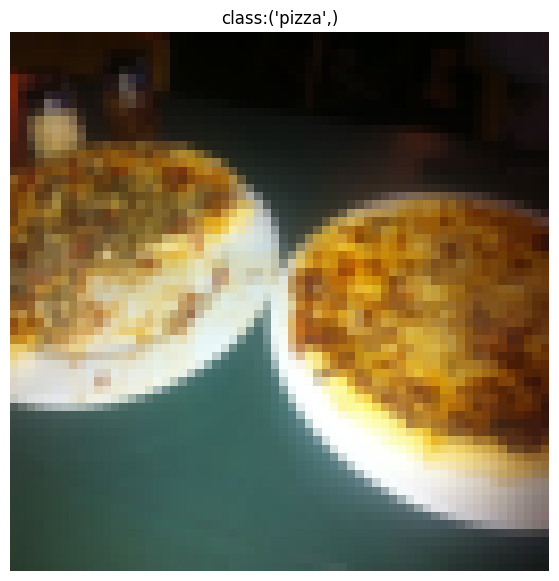

In [564]:
# rearrange the order of dimensions
img_permute = img.permute(1,2,0)
print(f"original shape:{img.shape} -> [color]")
print(f"permuted shape:{img_permute.shape}")

#plot
plt.figure(figsize=(10,7))
plt.imshow(img_permute)
plt.title(f"class:{class_names[label],}")
plt.axis("off")

## 4.1 Turn loaded images into `DataLoaders`

A dataloader is going to help us turn Datasets into iterables and we can customise the batch_size so our model can see batch_size images at a time.

In [565]:
os.cpu_count()

2

In [566]:
# turn train and test datsets into Dataloaders
from torch.utils.data import DataLoader

BATCH_SIZE = 1
train_dataloader= DataLoader(dataset=train_data,
                             batch_size=BATCH_SIZE,
                             shuffle=True,
                             num_workers=1
                             )
test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             shuffle=True,
                             num_workers=1)
train_dataloader,test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7da5e4d6c710>,
 <torch.utils.data.dataloader.DataLoader at 0x7da5fe817f90>)

In [567]:
len(train_dataloader),len(test_dataloader)

(225, 75)

In [568]:
img,label = next(iter(train_dataloader))

print(f"image shape : {img.shape}")
print(f"label shaep : {label.shape}")

image shape : torch.Size([1, 3, 64, 64])
label shaep : torch.Size([1])


## 5 optiont 2: Loading Image Data with a custom `Dataset`

1. Want to be able to load image from file.
2. Want to be able to get class names from the dataset
3. Want to able to get classes as dictionary from the dataset

Pros:
* can create a dataset out of almost anything.
* Not limited to pytorch pre-built dataset functions

Cons:
* Even though u could create dataset out of almost anyything, it doesnot mean it will work ...
* Using a custom dataset often result in us writing more code, which could be prone to errors or performance issues


All custom datasets in pytorch,often subclasses

In [569]:
import os
import pathlib
import torch

from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple,Dict,List

In [570]:
# instance of torchvision.datasets.imagefolder()
train_data.classes,train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

from posix import scandir
## 5.1 Creating a helper function to get class names

we want a function to:
1. Get the class names using `os.scandir()` to traverse a target directory (ideally the directory is in standard image classification format).
2. Raise an error if class name not found (something wrong with directory path)
3. Turn the classnames into a dict and a list and return them.

In [571]:
# setup path for target directory
target_directory = train_dir
print(f"Target dir :{target_directory}")

#get the class names from the target directory
class_names_founds = sorted([entry.name for entry in list(os.scandir(target_directory))])
class_names_founds

Target dir :data/pizza_steak_sushi/train


['pizza', 'steak', 'sushi']

In [572]:
list(os.scandir(target_directory))
#

[<DirEntry 'sushi'>, <DirEntry 'steak'>, <DirEntry 'pizza'>]

In [573]:
def find_classes(directory:str)-> Tuple[List[str],Dict[str,int]]:
  """Finds the class folder names in atarget directory"""
  #1. Get the class names by scanning the target directort
  classes = sorted([entry.name for entry in os.scandir(directory) if entry.is_dir()])


  #2. raise an error if classs names colud not be ound
  if not classes:
    raise FileNotFoundError(f"couldnt find any classes in {directory}...")

  #3. Create a dictionary if index labls (computers prefer numbers rather thn strings as labels)
  class_to_idx = {class_names: i for i , class_names in enumerate(classes)}
  return classes,class_to_idx

In [574]:
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

## 5.2 Create a custom dataset to replaces imagefolder

To create our own dataset we want to:

 1.Sublcass torch.utils.data.Dataset

 2.Init our cubclass with target directiry(from where wed like to get data from) as well aas a tranform if wed like to transform our data.

 3.Create several attributes.

  *paths-paths of our images.

  *transform=the transform ehich we like to use

  *classes-a list of the targe classes

  *class_to_idx=a dict of the target classes mapped to integer labels

 4.Create a function to load_images() this function will open an image
 5.Overwrite the __len()__ method to return the length of our dataset
 6.Overwrite the __getitem()__ method to return a given sample when apssed an index.  

In [575]:
#0 write a custom datset class
from torch.utils.data import Dataset
#1 subclass torch.utils.data.dataset
class ImagefolderCuston(Dataset):
  #2 initialise our custom dataset
  def __init__(self,
               target_dir:str,
               transform:transforms=None):
    #3 create clas attribute
    #get all of the image paths
    self.paths = list(pathlib.Path(target_dir).glob("*/*.jpg"))
    #setup trannsform
    self.transfom = transform
    # create classes and class_to_idx attributes
    self.classes,self.class_to_idx=find_classes(target_dir)

   # 4. Make function to load images
  def load_image(self, index: int) -> Image.Image:
      "Opens an image via a path and returns it."
      image_path = self.paths[index]
      return Image.open(image_path)


  #5 overwrite __len()__
  def __len__(self)->int:
    "return the totla number of samples"
    return len(self.paths)

  #6 overwrite __getitem__() method t o return a particular sample
  def __getitem__(self, index:int)-> Tuple[torch.Tensor,int]:
    "retunr one sample of data , data and label(X,y)."
    img = self.load_image(index)
    class_name = self.paths[index].parent.name
    class_idx = self.class_to_idx[class_name]

    # transform if necessary
    if self.transfom:
      return self.transfom(img),class_idx # return data.label(X,y)
    else:
      return img, class_idx# retunrn untransformed image and label

In [576]:
# create a tranform
from torchvision import transforms
train_transforms =transforms.Compose([
                                      transforms.Resize(size=(64,64)),
                                      transforms.RandomHorizontalFlip(p=0.5),
                                      transforms.ToTensor()])
test_transforms =transforms.Compose([
                                      transforms.Resize(size=(64,64)),

                                      transforms.ToTensor()])

In [577]:
#test out imagefoldercustom
train_data_custom = ImagefolderCuston(target_dir=train_dir,
                                      transform=train_transforms)
test_data_custom = ImagefolderCuston(target_dir=test_dir,
                                     transform=test_transforms)


In [578]:
train_data_custom,test_data_custom

(<__main__.ImagefolderCuston at 0x7da5fe46ba90>,
 <__main__.ImagefolderCuston at 0x7da5fe8affd0>)

In [579]:
len(train_data),len(train_data_custom)

(225, 225)

In [580]:
len(test_data),len(test_data_custom)

(75, 75)

In [581]:
train_data_custom.classes

['pizza', 'steak', 'sushi']

In [582]:
train_data_custom.class_to_idx

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [583]:
# chheck fot equality between original imagefolder and imagefolder custom
print(test_data_custom.classes == test_data.classes)
print(train_data_custom.classes==train_data.classes)

True
True


##5.3 Create a function to display random images

1. Take in a dataset and a number of other parametrs such as classnames and how many images to visulize,
2. To pevent the display getting out of hand lets cap the number of images to see at 10.
3. Set the random seed for reproducibility.
4. Get a list of random samples indexes from the target dataset
5. Setup a matplotlib plot
6. Loop through the random sample images and plot them with matplotlib
7. make sure the dimensions of our images line up wiht matplotlib(HWC).

In [584]:
#1 create a function to take in a dataset
def display_random_images(dataset: torch.utils.data.Dataset,
                          classes: List[str] = None,
                          n: int = 10,
                          display_shape:bool = True,
                          seed:int =None):
  #2 Adjust display if n is too high
  if n> 10:
    n=10
    display_shape=False
    print(f"for display, purposes, n shouldnt be larger than 10, setting to 10 and removing shape display")

  #3 set the seed
  if seed:
    random.seed(seed)

  #4 get random sample indexes
  random_smaple_indx = random.sample(range(len(dataset)),k=n)

  #5 setup plot
  plt.figure(figsize=(16,8))
  # plt.subplots_adjust(hspace=0.5)

  #6 loop through radnom indexes and plot them wth  matplotlob
  for i, targ_sample in enumerate (random_smaple_indx):
    targ_image,targ_label = dataset[targ_sample][0],dataset[targ_sample][1]

    #7 adjust tensor dimension for plotting
    targ_image_adjust = targ_image.permute(1,2,0)

    #8 plot
    plt.subplot(1,n,i+1)
    plt.imshow(targ_image_adjust)
    plt.axis("off")
    if classes:
      title = f"class :{classes[targ_label]}"
      if display_shape:
        title = title + f"\nshape: {targ_image_adjust.shape}"
      plt.title(title)

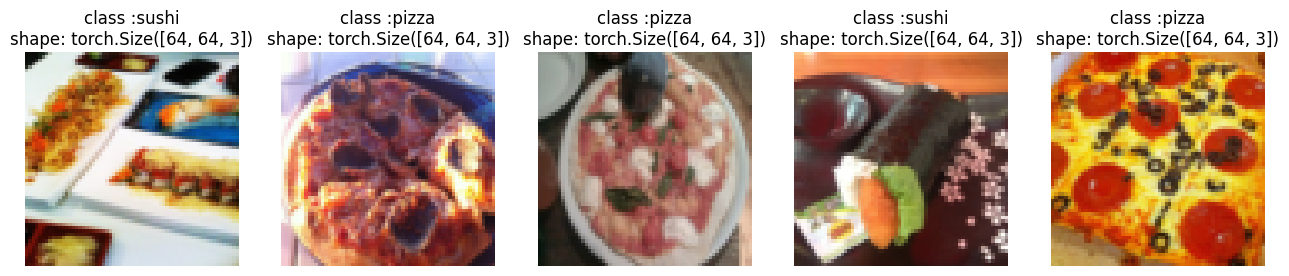

In [585]:
#display random image from the imagefolder inbuiltt
display_random_images(train_data,
                      classes=train_data.classes,
                      n=5,
                      seed=42)

for display, purposes, n shouldnt be larger than 10, setting to 10 and removing shape display


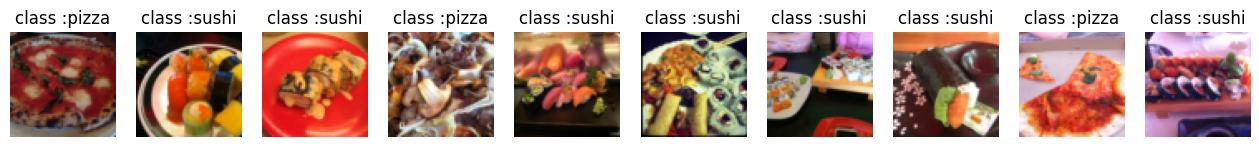

In [586]:
#display random images from imagefoldercustom
display_random_images(train_data_custom,
                      classes=class_names,
                      n=20,
                      seed=42)

## 5.4 turn custom loaded into DATAloaders

In [587]:
from torch.utils.data import DataLoader
BATCH_SIZE=32
train_dataloader_custom = DataLoader(dataset=train_data_custom,
                                     batch_size=BATCH_SIZE,
                                     shuffle=True,
                                     num_workers=1)
test_dataloader_custom = DataLoader(dataset=test_data_custom,
                                    batch_size = BATCH_SIZE,
                                    shuffle=False,
                                    num_workers=1)

In [588]:
train_dataloader_custom,test_dataloader_custom

(<torch.utils.data.dataloader.DataLoader at 0x7da5e5e37290>,
 <torch.utils.data.dataloader.DataLoader at 0x7da5e5fb0190>)

In [589]:
# get image and label from custom dataloader
img_custom , label_custom = next(iter(train_dataloader_custom))

#print out the shape
img_custom.shape,label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

## 6 other forms of transform (DATA AUGMENTATION)

DATA augmentation is the process of artificially adding diversity to your training data.

In case of image data , this may mean applying various image transformations to the training images.

Lets take a look at one particular type of data augmentation used to train pytorch vision models to state of the art (SOTA).


In [590]:
# lets look at trivail augment
from torchvision import transforms

train_transform = transforms.Compose([transforms.Resize(size=(224,224)),
                                      transforms.TrivialAugmentWide(num_magnitude_bins=31),
                                      transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize(size=(224,224)),
                                      transforms.ToTensor()])

In [591]:
## get all image paths
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[:10]

[PosixPath('data/pizza_steak_sushi/test/sushi/46797.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/2521706.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/2394442.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/2385731.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/343036.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/3837522.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/207578.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/1172255.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/1600999.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/2276986.jpg')]

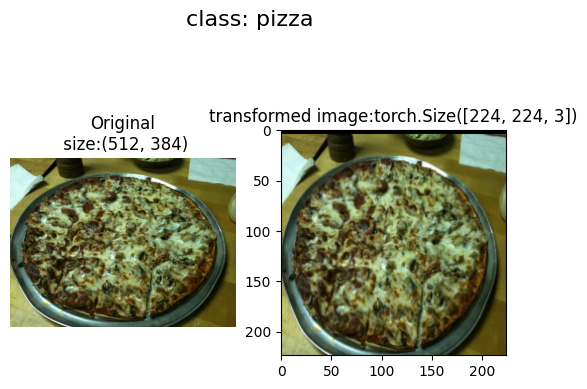

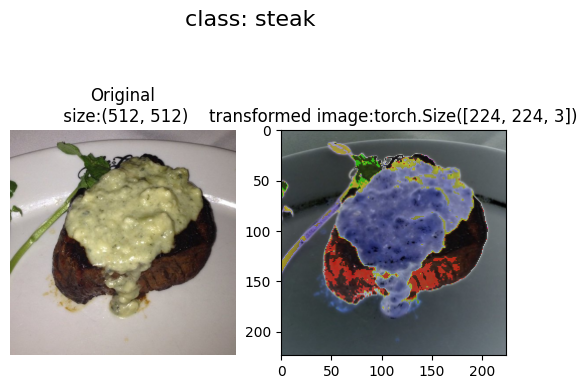

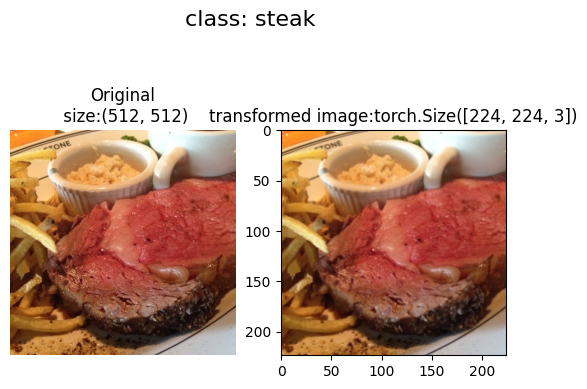

In [592]:
#plot random tivial augmented images
plot_tranformed_images(image_paths=image_path_list,
                       transform=train_transform,
                       n=3,
                       seed=None)

### 7. Model 0 : TinyVGG wihtout data augmentation
lets replicate TinyVGG from the CNN explainer website

##7.1 Creating transforms and loading data for model0

In [593]:
# Create simple transform
simple_transform = transforms.Compose([
    transforms.Resize(size=(64,64)),
    transforms.ToTensor()
])

In [594]:
# 1. load and transform data
from torchvision import datasets
train_data_simple = datasets.ImageFolder(root=train_dir,
                                         transform=simple_transform,
                                         target_transform=None)
test_data_simple = datasets.ImageFolder(root=test_dir,
                                        transform=simple_transform,
                                        target_transform=None)
# turn into dataloaders
import os
from torch.utils.data import DataLoader
# set batch size
BATCH_SIZE=32
NUM_WORKERS =os.cpu_count()

# create dataloader
train_dataloader_simple = DataLoader(dataset=train_data_simple,
                                     batch_size=BATCH_SIZE,
                                     shuffle=True,
                                     num_workers=NUM_WORKERS)

test_dataloader_simple = DataLoader(dataset=test_data_simple,
                                    batch_size=BATCH_SIZE,
                                    shuffle=False,
                                    num_workers=NUM_WORKERS)

## 7.2 Create tinyvgg model class

In [595]:
from torch import nn

In [596]:
# #model
# class TinyVGG(nn.Module):
#   def __init__(self,input_shape:int,hidden_unit:int,output_shape:int)-> None:
#     super().__init__()
#     self.conv_layer_block_1=nn.Sequential(
#         nn.Conv2d(in_channels=input_shape,
#                   out_channels=hidden_unit,
#                   kernel_size=3,
#                   stride=1,
#                   padding=0),
#         nn.ReLU(),
#         nn.Conv2d(in_channels=hidden_unit,
#                   out_channels=hidden_unit,
#                   kernel_size=3,
#                   stride=1,
#                   padding=0),
#         nn.ReLU(),
#         nn.MaxPool2d(kernel_size=2, stride=2)

#     )
#     self.conv_layer_block_2=nn.Sequential(
#         nn.Conv2d(in_channels=hidden_unit,
#                   out_channels=hidden_unit,
#                   kernel_size=3,
#                   stride=1,
#                   padding=0),
#         nn.ReLU(),
#         nn.Conv2d(in_channels=hidden_unit,
#                   out_channels=hidden_unit,
#                   kernel_size=3,
#                   stride=1,
#                   padding=0),
#         nn.ReLU(),
#         nn.MaxPool2d(kernel_size=2, stride=2)

#     )
#     self.classifier_layer = nn.Sequential(
#         nn.Flatten(),
#         nn.Linear(in_features=hidden_unit*13*13,
#                   out_features=output_shape)
#     )

#   def forward(self,x):
#     x=self.conv_layer_block_1(x)
#     # print(x.shape)
#     x=self.conv_layer_block_2(x)
#     # print(x.shape)
#     x=self.classifier_layer(x)
#     # print(x.shape)
#     return x
class TinyVGG(nn.Module):
    """
    Model architecture copying TinyVGG from:
    https://poloclub.github.io/cnn-explainer/
    """
    def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
        super().__init__()
        self.conv_block_1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape,
                      out_channels=hidden_units,
                      kernel_size=3, # how big is the square that's going over the image?
                      stride=1, # default
                      padding=1), # options = "valid" (no padding) or "same" (output has same shape as input) or int for specific number
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units,
                      out_channels=hidden_units,
                      kernel_size=3,
                      stride=1,
                      padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2) # default stride value is same as kernel_size
        )
        self.conv_block_2 = nn.Sequential(
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(hidden_units, hidden_units, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2,
                         stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            # Where did this in_features shape come from?
            # It's because each layer of our network compresses and changes the shape of our input data.
            nn.Linear(in_features=hidden_units*16*16,
                      out_features=output_shape)
        )

    def forward(self, x: torch.Tensor):
        x = self.conv_block_1(x)
        # print(x.shape)
        x = self.conv_block_2(x)
        # print(x.shape)
        x = self.classifier(x)
        # print(x.shape)
        return x
        # return self.classifier(self.conv_block_2(self.conv_block_1(x))) # <- leverage the benefits of operator fusion

torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3, # number of color channels (3 for RGB)
                  hidden_units=10,
                  output_shape=len(train_data.classes)).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2560, out_features=3, bias=True)
  )
)

### 7.3 try a forward pas on a single image (tot est the model)

In [597]:
# get a single image batch
image_batch ,label_batch = next(iter(train_dataloader_simple))
image_batch.shape,label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [598]:
#try forward pass
model_0(image_batch.to(device))

tensor([[0.0578, 0.0634, 0.0351],
        [0.0657, 0.0650, 0.0398],
        [0.0702, 0.0678, 0.0412],
        [0.0687, 0.0646, 0.0417],
        [0.0625, 0.0613, 0.0355],
        [0.0587, 0.0595, 0.0358],
        [0.0634, 0.0637, 0.0376],
        [0.0653, 0.0615, 0.0376],
        [0.0678, 0.0621, 0.0349],
        [0.0620, 0.0599, 0.0371],
        [0.0607, 0.0628, 0.0387],
        [0.0638, 0.0589, 0.0352],
        [0.0658, 0.0611, 0.0369],
        [0.0703, 0.0689, 0.0330],
        [0.0557, 0.0571, 0.0356],
        [0.0632, 0.0642, 0.0388],
        [0.0639, 0.0616, 0.0375],
        [0.0605, 0.0600, 0.0374],
        [0.0623, 0.0627, 0.0368],
        [0.0740, 0.0676, 0.0400],
        [0.0621, 0.0613, 0.0361],
        [0.0632, 0.0599, 0.0366],
        [0.0662, 0.0627, 0.0334],
        [0.0637, 0.0622, 0.0394],
        [0.0670, 0.0666, 0.0363],
        [0.0650, 0.0601, 0.0405],
        [0.0639, 0.0597, 0.0395],
        [0.0733, 0.0687, 0.0412],
        [0.0697, 0.0631, 0.0402],
        [0.062

### 7.4 use torchinfo to get an idea of the shapes going through our model

In [599]:
pip install torchinfo


In [600]:
from torchinfo import summary


summary(model_0, input_size=(1, 3, 64,64))

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           280
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           910
│    └─ReLU: 2-4                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 10, 32, 32]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 10, 32, 32]           910
│    └─ReLU: 2-7                         [1, 10, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 10, 32, 32]           910
│    └─ReLU: 2-9                         [1, 10, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 10, 16, 16]           --
├─Sequentia

## 7.5 create train and test loops

train_step()

test_step()

In [601]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer):
    # Put model in train mode
    model.train()

    # Setup train loss and train accuracy values
    train_loss, train_acc = 0, 0

    # Loop through data loader data batches
    for batch, (X, y) in enumerate(dataloader):
        # Send data to target device
        # X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X)

        # 2. Calculate  and accumulate loss
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

        # Calculate and accumulate accuracy metrics across all batches
        y_pred_class = torch.argmax(torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (y_pred_class == y).sum().item()/len(y_pred)

    # Adjust metrics to get average loss and accuracy per batch
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    return train_loss, train_acc

In [602]:
# def test_step(model:torch.nn.Module,
#               dataloader:torch.utils.data.DataLoader,
#               loss_fn:loss_fn,
#               device:device,
#               ):
#   test_Acc,test_loss=0,0
#   model.eval()
#   with torch.inference_mode():
#     for batch,(X,y) in enumerate(dataloader):
#       X,y = X.to(device),y.to(device)
#       test_pred =model(X),
#       loss =loss_fn(test_pred,y)
#       test_loss += loss.item()
#       y_test_pred = torch.argmax(torch.softmax(test_pred,dim=1),dim=1)
#       test_Acc += (y_test_pred == y).sum().item()/len(y_test_pred)
#   test_loss = test_loss/len(dataloader)
#   test_Acc = test_Acc/len(dataloader)
#   return test_loss,test_Acc
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module):
    # Put model in eval mode
    model.eval()

    # Setup test loss and test accuracy values
    test_loss, test_acc = 0, 0

    # Turn on inference context manager
    with torch.inference_mode():
        # Loop through DataLoader batches
        for batch, (X, y) in enumerate(dataloader):
            # Send data to target device
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred_logits = model(X)

            # 2. Calculate and accumulate loss
            loss = loss_fn(test_pred_logits, y)
            test_loss += loss.item()

            # Calculate and accumulate accuracy
            test_pred_labels = test_pred_logits.argmax(dim=1)
            test_acc += ((test_pred_labels == y).sum().item()/len(test_pred_labels))

    # Adjust metrics to get average loss and accuracy per batch
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    return test_loss, test_acc

In [603]:
# from tqdm.auto import tqdm
# def train (model:torch.nn.Module,
#            train_dataloader: torch.utils.data.DataLoader,
#            test_dataloader: torch.utils.data.DataLoader,
#            loss_fn: torch.nn.Module,
#            optimizer:torch.optim.Optimizer,
#            device:torch.device,
#            epochs:int=5):

#   results = {"train_loss":[],
#              "train_acc":[],
#              "test_loss":[],
#              "test_acc":[]}

#   for epoch in tqdm(range(epochs)):
#     print(f"epoch: {epoch+1}....\n")
#     train_loss,train_acc =train_step(model=model_0,
#                dataloader= train_data_simple,
#                loss_fn=loss_fn,
#                optimizer=optimizer,
#                )
#     test_loss,test_Acc = test_step(model=model_0,
#               dataloader=test_data_simple,
#               loss_fn=loss_fn,
#               )
#     print(f"Epoch:{epoch} | train loss: {train_loss:.4f} | train acc: {train_acc:.4f} | test loss: {test_loss:.4f} | test acc: {test_Acc:.4f}")

#     results["train_loss"].append(train_loss)
#     results["train_acc"].append(train_acc)
#     results["test_loss"].append(test_loss)
#     results["test_acc"].append(test_Acc)

#   return results
from tqdm.auto import tqdm

# 1. Take in various parameters required for training and test steps
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          epochs: int = 10):

    # 2. Create empty results dictionary
    results = {"train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    # 3. Loop through training and testing steps for a number of epochs
    for epoch in tqdm(range(epochs)):
        train_loss, train_acc = train_step(model=model,
                                           dataloader=train_dataloader,
                                           loss_fn=loss_fn,
                                           optimizer=optimizer)
        test_loss, test_acc = test_step(model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn)

        # 4. Print out what's happening
        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        # 5. Update results dictionary
        # Ensure all data is moved to CPU and converted to float for storage
        results["train_loss"].append(train_loss.item() if isinstance(train_loss, torch.Tensor) else train_loss)
        results["train_acc"].append(train_acc.item() if isinstance(train_acc, torch.Tensor) else train_acc)
        results["test_loss"].append(test_loss.item() if isinstance(test_loss, torch.Tensor) else test_loss)
        results["test_acc"].append(test_acc.item() if isinstance(test_acc, torch.Tensor) else test_acc)

    # 6. Return the filled results at the end of the epochs
    return results

In [609]:
# torch.manual_seed(42)
# torch.cuda.manual_seed(42)

# NUM_EPOCHS =5

# model_0 = TinyVGG(input_shape=3,
#                   hidden_units=10,
#                   output_shape=len(train_data.classes)).to(device)

# loss_fn = nn.CrossEntropyLoss()
# optimizer=torch.optim.Adam(params=model_0.parameters(),
#                            lr=0.001)

# from timeit import default_timer as timer
# start_timer =timer()
# model_0_results = train(model=model_0,
#                         train_dataloader=train_dataloader_simple,
#                         test_dataloader=test_dataloader_simple,
#                         optimizer=optimizer,
#                         loss_fn=loss_fn,

#                         epochs=NUM_EPOCHS)
# ed_time=timer
# print(f"time taken for training: {ed_time-start_timer:.3f} seconds")
# Set random seeds
torch.manual_seed(42)
torch.cuda.manual_seed(42)

# Set number of epochs
NUM_EPOCHS = 20

# Recreate an instance of TinyVGG
model_0 = TinyVGG(input_shape=3, # number of color channels (3 for RGB)
                  hidden_units=10,
                  output_shape=len(train_data.classes)).to(device)

# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model_0.parameters(), lr=0.001)

# Start the timer
from timeit import default_timer as timer
start_time = timer()

# Train model_0
model_0_results = train(model=model_0,
                        train_dataloader=train_dataloader_simple,
                        test_dataloader=test_dataloader_simple,
                        optimizer=optimizer,
                        loss_fn=loss_fn,
                        epochs=NUM_EPOCHS)

# End the timer and print out how long it took
end_time = timer()
print(f"Total training time: {end_time-start_time:.3f} seconds")

  0%|          | 0/20 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.1078 | train_acc: 0.2578 | test_loss: 1.1362 | test_acc: 0.2604
Epoch: 2 | train_loss: 1.0846 | train_acc: 0.4258 | test_loss: 1.1622 | test_acc: 0.1979
Epoch: 3 | train_loss: 1.1153 | train_acc: 0.2930 | test_loss: 1.1695 | test_acc: 0.1979
Epoch: 4 | train_loss: 1.0990 | train_acc: 0.2891 | test_loss: 1.1343 | test_acc: 0.1979
Epoch: 5 | train_loss: 1.0990 | train_acc: 0.2930 | test_loss: 1.1434 | test_acc: 0.1979
Epoch: 6 | train_loss: 1.0964 | train_acc: 0.3125 | test_loss: 1.1483 | test_acc: 0.2604
Epoch: 7 | train_loss: 1.1187 | train_acc: 0.3203 | test_loss: 1.1422 | test_acc: 0.3125
Epoch: 8 | train_loss: 1.1015 | train_acc: 0.3555 | test_loss: 1.1051 | test_acc: 0.1979
Epoch: 9 | train_loss: 1.0893 | train_acc: 0.4688 | test_loss: 1.0686 | test_acc: 0.5417
Epoch: 10 | train_loss: 1.0682 | train_acc: 0.4023 | test_loss: 1.0172 | test_acc: 0.5417
Epoch: 11 | train_loss: 1.0499 | train_acc: 0.4062 | test_loss: 0.9775 | test_acc: 0.5729
Epoch: 12 | train_l

## 7.8 plot the loss curve of model 0


In [610]:
# get the model_0_results keys
model_0_results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

In [612]:
def plot_loss_curves(results:Dict[str,List[float]]):
  #get the loss values of the results dictionary(training and test)
  loss=results["train_loss"]
  test_loss = results["test_loss"]

  #get the accuracy values of the results dictionary (training and test)
  accuracy = results["train_acc"]
  test_accuracy = results["test_acc"]

  #figure out how many epochs ther were
  epochs = range(len(results["train_loss"]))

  #setup a plot
  plt.figure(figsize=(15,7))

  #plot the loss
  plt.subplot(1,2,1)
  plt.plot(epochs,loss,label="train_loss")
  plt.plot(epochs,test_loss,label="test_loss")
  plt.title("loss")
  plt.xlabel("epochs")
  plt.legend()

  #plot the accuracy
  plt.subplot(1,2,2)
  plt.plot(epochs,accuracy,label="train_accuracy")
  plt.plot(epochs,test_accuracy,label="test_accuracy")
  plt.title("accuracy")
  plt.xlabel("epochs")
  plt.legend()

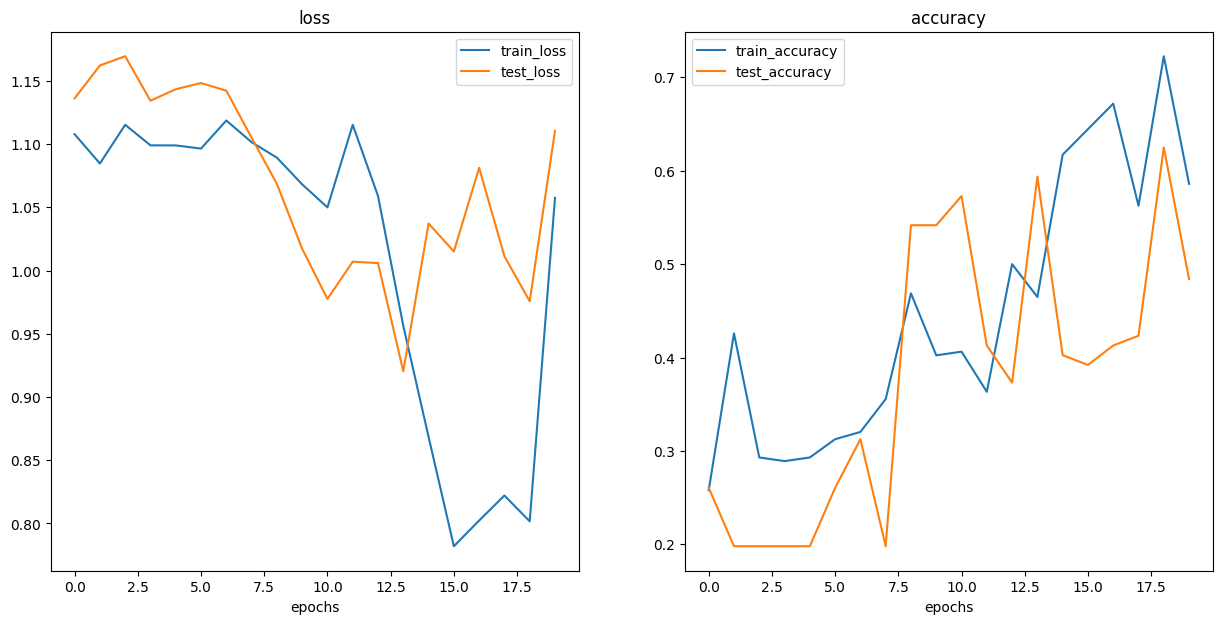

In [613]:
plot_loss_curves(model_0_results)

## 8. WHat should an ideal loss curve look like?

a loss curve is one of the most helpful ways to troubleshoot a model.